# 🏐 Lab 1 — Web Crawling + NER
**Course:** Web Mining & Semantics  
**Domain:** International Men's Volleyball (FIVB)  
**Sources:** Wikipedia API + Wikidata SPARQL  

### Pipeline Overview
```
Wikipedia API ──► Text Cleaning ──► NER (spaCy) ──► extracted_knowledge.csv
Wikidata SPARQL ──────────────────────────────────► wikidata_output.jsonl
NER output ──────────────────────────────────────► Relation Extraction
```

### ⚖️ Web Ethics & Crawling Policy
This crawler follows responsible web scraping practices:
- **Wikipedia API** is used instead of direct HTML scraping — this is the officially recommended access method per Wikipedia's [Terms of Use](https://foundation.wikimedia.org/wiki/Policy:Terms_of_Use)
- **Wikidata SPARQL endpoint** is public and free to query with a proper `User-Agent` header
- **Rate limiting**: 0.5s delay between Wikipedia API calls to avoid overloading servers
- **User-Agent**: identifies the bot as an academic project as required by Wikipedia's robots.txt
- **robots.txt compliance**: Wikipedia's robots.txt allows API access; Wikidata explicitly permits SPARQL queries

### Outputs
| File | Description |
|------|-------------|
| `crawler_output.jsonl` | Cleaned Wikipedia text + metadata per page |
| `wikidata_output.jsonl` | Structured Wikidata query results |
| `extracted_knowledge.csv` | Named entities (type, text, sentence context, source) |
| `extracted_relations.csv` | Candidate triples (subject, verb, object) |

## ⚙️ 0. Setup & Installations

In [1]:
# Install dependencies
!pip install -q trafilatura httpx SPARQLWrapper pandas wikipedia-api
!pip install -q spacy
!python -m spacy download en_core_web_trf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 39.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to r

In [2]:
# Mount Google Drive to save outputs
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/volleyball-kg/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/volleyball-kg/data


In [3]:
# Imports
import json
import time
import httpx
import trafilatura
import pandas as pd
import spacy
import wikipediaapi
from SPARQLWrapper import SPARQLWrapper, JSON
from urllib.parse import urlparse

# Load spaCy model
nlp = spacy.load('en_core_web_trf')
print('All imports OK ✅')

All imports OK ✅


## 🌐 1. Phase 1 — Wikipedia Crawling

In [4]:
# ── Seed URLs ──────────────────────────────────────────────────────────────
# Covers: national teams, players, tournaments, clubs
SEED_URLS = [
    # National Teams
    'https://en.wikipedia.org/wiki/Brazil_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/France_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/Poland_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/Italy_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/United_States_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/Japan_men%27s_national_volleyball_team',
    'https://en.wikipedia.org/wiki/Argentina_men%27s_national_volleyball_team',
    # Tournaments
    'https://en.wikipedia.org/wiki/FIVB_Volleyball_Nations_League',
    'https://en.wikipedia.org/wiki/FIVB_Volleyball_World_Championship',
    'https://en.wikipedia.org/wiki/Volleyball_at_the_Summer_Olympics',
    'https://en.wikipedia.org/wiki/FIVB_Volleyball_World_Cup',
    # Players
    'https://en.wikipedia.org/wiki/Earvin_Ngapeth',
    'https://en.wikipedia.org/wiki/Wilfredo_Le%C3%B3n',
    'https://en.wikipedia.org/wiki/Nimir_Abdel-Aziz',
    'https://en.wikipedia.org/wiki/Giba',
    'https://en.wikipedia.org/wiki/Bartosz_Kurek',
    'https://en.wikipedia.org/wiki/Ivan_Zaytsev',
    'https://en.wikipedia.org/wiki/Matthew_Anderson_(volleyball)',
    'https://en.wikipedia.org/wiki/Bruno_Rezende',
    # Clubs
    'https://en.wikipedia.org/wiki/Trentino_Volley',
    'https://en.wikipedia.org/wiki/Sir_Sicoma_Monini_Perugia',
    'https://en.wikipedia.org/wiki/Paris_Volley',
    # Federations
    'https://en.wikipedia.org/wiki/FIVB',
    'https://en.wikipedia.org/wiki/Confédération_Européenne_de_Volleyball',
]

print(f'Total seed URLs: {len(SEED_URLS)}')

Total seed URLs: 24


In [5]:
# Use Wikipedia API — official access method, no 403 issues
# User-Agent identifies us as an academic project (required by Wikipedia ToS)
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='VolleyballKG-Bot/1.0 (academic research project, non-commercial)'
)

WIKI_PAGES = [
    # === National Teams ===
    "Brazil men's national volleyball team",
    "France men's national volleyball team",
    "Poland men's national volleyball team",
    "Italy men's national volleyball team",
    "United States men's national volleyball team",
    "Japan men's national volleyball team",
    "Russia men's national volleyball team",
    "Argentina men's national volleyball team",
    "Serbia men's national volleyball team",
    "Cuba men's national volleyball team",
    "Slovenia men's national volleyball team",
    # === Tournaments (specific editions to get richer content) ===
    "2024 FIVB Volleyball Nations League – Men",
    "2023 FIVB Volleyball Nations League – Men",
    "2022 FIVB Volleyball World Championship – Men",
    "2018 FIVB Volleyball World Championship",
    "Volleyball at the 2024 Summer Olympics – Men's tournament",
    "Volleyball at the 2020 Summer Olympics – Men's tournament",
    "Volleyball at the Summer Olympics",
    "2021 FIVB Volleyball World Cup",
    "CEV Champions League Volleyball – Men 2023–24",
    # === Players ===
    "Earvin Ngapeth",
    "Wilfredo León",
    "Nimir Abdel-Aziz",
    "Giba",
    "Bartosz Kurek",
    "Ivan Zaytsev",
    "Matthew Anderson (volleyball)",
    "Bruno Rezende",
    "Micah Christenson",
    "Maxim Mikhaylov",
    "Aleksandar Atanasijević",
    "Facundo Conte",
    "Yoandy Leal",
    "Osmany Juantorena",
    "Robertlandy Simón",
    # === Clubs ===
    "Trentino Volley",
    "Cucine Lube Civitanova",
    "Zenit Kazan",
    "Asseco Resovia",
    "Paris Volley",
    # === Federations & Orgs ===
    "FIVB",
    "Confédération Européenne de Volleyball",
    "Volleyball",
]

def is_useful_page(text: str, min_words: int = 200) -> bool:
    """Check if extracted text meets minimum length threshold.
    Lowered to 200 words to capture shorter but valid pages (player bios, small clubs).
    """
    return len(text.split()) >= min_words

def fetch_wikipedia_page(title: str) -> dict | None:
    """
    Fetch a Wikipedia page by title using the official Wikipedia API.
    Respects rate limiting and ToS — no direct HTML scraping.
    Returns dict with title, url, text, word_count — or None if not useful.
    """
    try:
        page = wiki.page(title)
        if not page.exists():
            print(f'  [SKIP] Page not found: {title}')
            return None
        text = page.text
        if not is_useful_page(text):
            print(f'  [SKIP] Too short ({len(text.split())} words): {title}')
            return None
        return {
            'url': page.fullurl,
            'title': title,
            'text': text,
            'word_count': len(text.split())
        }
    except Exception as e:
        print(f'  [ERROR] {title}: {e}')
        return None

print(f'Total pages to fetch: {len(WIKI_PAGES)}')
print(f'Minimum word threshold: 200 words')

Total pages to fetch: 43
Minimum word threshold: 200 words


In [6]:
# Crawl all Wikipedia pages via API
crawled_pages = []
DELAY_SECONDS = 0.5

print('Starting Wikipedia crawl via API...\n')
for i, title in enumerate(WIKI_PAGES):
    print(f'[{i+1}/{len(WIKI_PAGES)}] Fetching: {title}')
    result = fetch_wikipedia_page(title)
    if result:
        crawled_pages.append(result)
        print(f'  [OK] {result["word_count"]} words')
    time.sleep(DELAY_SECONDS)

print(f'\n✅ Successfully crawled: {len(crawled_pages)}/{len(WIKI_PAGES)} pages')

Starting Wikipedia crawl via API...

[1/43] Fetching: Brazil men's national volleyball team
  [OK] 849 words
[2/43] Fetching: France men's national volleyball team
  [OK] 419 words
[3/43] Fetching: Poland men's national volleyball team
  [OK] 4576 words
[4/43] Fetching: Italy men's national volleyball team
  [OK] 733 words
[5/43] Fetching: United States men's national volleyball team
  [OK] 535 words
[6/43] Fetching: Japan men's national volleyball team
  [OK] 1598 words
[7/43] Fetching: Russia men's national volleyball team
  [OK] 330 words
[8/43] Fetching: Argentina men's national volleyball team
  [OK] 455 words
[9/43] Fetching: Serbia men's national volleyball team
  [OK] 788 words
[10/43] Fetching: Cuba men's national volleyball team
  [OK] 1117 words
[11/43] Fetching: Slovenia men's national volleyball team
  [OK] 543 words
[12/43] Fetching: 2024 FIVB Volleyball Nations League – Men
  [SKIP] Page not found: 2024 FIVB Volleyball Nations League – Men
[13/43] Fetching: 2023 FIVB Vol

In [7]:
# ── Save to JSONL ──────────────────────────────────────────────────────────
JSONL_PATH = f'{OUTPUT_DIR}/crawler_output.jsonl'

with open(JSONL_PATH, 'w', encoding='utf-8') as f:
    for page in crawled_pages:
        f.write(json.dumps(page, ensure_ascii=False) + '\n')

print(f'Saved {len(crawled_pages)} pages → {JSONL_PATH}')

Saved 35 pages → /content/drive/MyDrive/volleyball-kg/data/crawler_output.jsonl


## 🗺️ 2. Phase 1b — Wikidata SPARQL: Entities + Relations

Wikidata is used as the **primary source for structured relations**.
Unlike dependency parsing on Wikipedia text (which yields noisy co-occurrences
on tabular sports content), Wikidata provides clean, typed, semantically rich
triples directly usable for Knowledge Graph construction.

Relations extracted here:
| Wikidata property | Relation label | Example |
|---|---|---|
| P54 | `playsFor` | Ngapeth → France |
| P27 | `citizenOf` | Ngapeth → France |
| P19 | `bornIn` | Ngapeth → Caen |
| P569 | `birthDate` | Ngapeth → 1989 |
| P413 | `playsPosition` | Ngapeth → Outside hitter |
| P17 | `teamFromCountry` | France team → France |
| P118 | `competesIn` | France team → FIVB |
| P664 | `organizedBy` | VNL → FIVB |
| P1532 | `representsCountry` | Ngapeth → France |

In [8]:
def query_wikidata(sparql_query: str) -> list[dict]:
    """Execute a SPARQL query on Wikidata and return results as a list of dicts."""
    endpoint = SPARQLWrapper('https://query.wikidata.org/sparql')
    endpoint.setQuery(sparql_query)
    endpoint.setReturnFormat(JSON)
    endpoint.addCustomHttpHeader('User-Agent', 'VolleyballKG-Bot/1.0 (academic project)')
    results = endpoint.query().convert()
    return results['results']['bindings']

In [9]:
# ── Query 1: Male volleyball players ──────────────────────────────────────
QUERY_PLAYERS = """
SELECT DISTINCT ?player ?playerLabel ?nationalityLabel ?birthDate ?positionLabel WHERE {
  ?player wdt:P31 wd:Q5 ;                      # is a human
          wdt:P106 wd:Q15117302 ;               # occupation: volleyball player
          wdt:P21 wd:Q6581097 .                 # gender: male
  OPTIONAL { ?player wdt:P27 ?nationality . }
  OPTIONAL { ?player wdt:P569 ?birthDate . }
  OPTIONAL { ?player wdt:P413 ?position . }     # playing position
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 500
"""

print('Querying Wikidata: volleyball players...')
players_raw = query_wikidata(QUERY_PLAYERS)
print(f'Found {len(players_raw)} players')

Querying Wikidata: volleyball players...
Found 500 players


In [10]:
# ── Query 2: Men's national volleyball teams ───────────────────────────────
QUERY_TEAMS = """
SELECT DISTINCT ?team ?teamLabel ?countryLabel ?federationLabel WHERE {
  ?team wdt:P31 wd:Q6979593 .                   # men's national volleyball team
  OPTIONAL { ?team wdt:P17 ?country . }
  OPTIONAL { ?team wdt:P118 ?federation . }      # league/federation
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 200
"""

print('Querying Wikidata: national teams...')
teams_raw = query_wikidata(QUERY_TEAMS)
print(f'Found {len(teams_raw)} teams')

Querying Wikidata: national teams...
Found 200 teams


In [11]:
# ── Query 3: Volleyball tournaments/competitions ───────────────────────────
QUERY_TOURNAMENTS = """
SELECT DISTINCT ?tournament ?tournamentLabel ?organizerLabel ?inceptionYear WHERE {
  ?tournament wdt:P31/wdt:P279* wd:Q13406554 .  # volleyball competition
  OPTIONAL { ?tournament wdt:P664 ?organizer . }
  OPTIONAL { ?tournament wdt:P571 ?inception .
             BIND(YEAR(?inception) AS ?inceptionYear) }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 100
"""

print('Querying Wikidata: tournaments...')
tournaments_raw = query_wikidata(QUERY_TOURNAMENTS)
print(f'Found {len(tournaments_raw)} tournaments')

Querying Wikidata: tournaments...
Found 100 tournaments


In [12]:
# Query 4: Player <-> National Team memberships (via country for sport)
QUERY_MEMBERSHIPS = """
SELECT DISTINCT ?playerLabel ?teamLabel ?countryLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P1532 ?country .
  ?team wdt:P31 wd:Q6979593 ;
        wdt:P17 ?country .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 500
"""

print('Querying Wikidata: player-team memberships...')
try:
    memberships_raw = query_wikidata(QUERY_MEMBERSHIPS)
    print(f'Found {len(memberships_raw)} memberships')
except Exception as e:
    print(f'Query failed: {e} — using empty list')
    memberships_raw = []


Querying Wikidata: player-team memberships...
Found 500 memberships


In [13]:
# ── Wikidata Relation Queries ─────────────────────────────────────────────
# These replace dependency parsing — Wikidata gives clean typed relations

print('Querying Wikidata structured relations...\n')

# ── Relation 1: Player playsFor national team ──────────────────────────────
QUERY_PLAYS_FOR = """
SELECT DISTINCT ?playerLabel ?teamLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P54 ?team .
  ?team wdt:P31 wd:Q6979593 .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 500
"""

# ── Relation 2: Player bornIn city/country ─────────────────────────────────
QUERY_BORN_IN = """
SELECT DISTINCT ?playerLabel ?cityLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P19 ?city .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 500
"""

# ── Relation 3: Player citizenOf country ───────────────────────────────────
QUERY_CITIZEN_OF = """
SELECT DISTINCT ?playerLabel ?countryLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P27 ?country .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 500
"""

# ── Relation 4: Player playsPosition ──────────────────────────────────────
QUERY_POSITION = """
SELECT DISTINCT ?playerLabel ?positionLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P413 ?position .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 500
"""

# ── Relation 5: Team fromCountry ───────────────────────────────────────────
QUERY_TEAM_COUNTRY = """
SELECT DISTINCT ?teamLabel ?countryLabel WHERE {
  ?team wdt:P31 wd:Q6979593 ;
        wdt:P17 ?country .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 300
"""

# ── Relation 6: Team competesIn federation ─────────────────────────────────
QUERY_TEAM_FEDERATION = """
SELECT DISTINCT ?teamLabel ?federationLabel WHERE {
  ?team wdt:P31 wd:Q6979593 ;
        wdt:P118 ?federation .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 300
"""

# ── Relation 7: Tournament organizedBy ────────────────────────────────────
QUERY_TOURNAMENT_ORGANIZER = """
SELECT DISTINCT ?tournamentLabel ?organizerLabel WHERE {
  ?tournament wdt:P31/wdt:P279* wd:Q13406554 ;
              wdt:P664 ?organizer .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 200
"""

# ── Relation 8: Player representsCountry (for sport) ──────────────────────
QUERY_REPRESENTS = """
SELECT DISTINCT ?playerLabel ?countryLabel WHERE {
  ?player wdt:P31 wd:Q5 ;
          wdt:P106 wd:Q15117302 ;
          wdt:P21 wd:Q6581097 ;
          wdt:P1532 ?country .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
} LIMIT 500
"""

# ── Execute all relation queries ───────────────────────────────────────────
relation_queries = [
    (QUERY_PLAYS_FOR,          'playsFor',          'player', 'team'),
    (QUERY_BORN_IN,            'bornIn',            'player', 'city'),
    (QUERY_CITIZEN_OF,         'citizenOf',         'player', 'country'),
    (QUERY_POSITION,           'playsPosition',     'player', 'position'),
    (QUERY_TEAM_COUNTRY,       'fromCountry',       'team',   'country'),
    (QUERY_TEAM_FEDERATION,    'competesIn',        'team',   'federation'),
    (QUERY_TOURNAMENT_ORGANIZER,'organizedBy',      'tournament','organizer'),
    (QUERY_REPRESENTS,         'representsCountry', 'player', 'country'),
]

wikidata_relations = []

for query, rel_label, subj_key, obj_key in relation_queries:
    try:
        results = query_wikidata(query)
        subj_col = f'{subj_key}Label'
        obj_col  = f'{obj_key}Label'
        for r in results:
            subj = r.get(subj_col, {}).get('value', '')
            obj  = r.get(obj_col,  {}).get('value', '')
            if subj and obj:
                wikidata_relations.append({
                    'subject':      subj,
                    'relation':     rel_label,
                    'object':       obj,
                    'pattern':      'wikidata_structured',
                    'source_url':   'https://www.wikidata.org'
                })
        print(f'  [{rel_label:<22}] {len(results):>4} triples')
        time.sleep(0.5)  # polite delay
    except Exception as e:
        print(f'  [{rel_label:<22}] FAILED: {e}')

print(f'\n✅ Total Wikidata relations: {len(wikidata_relations)}')


Querying Wikidata structured relations...

  [playsFor              ]    0 triples
  [bornIn                ]  500 triples
  [citizenOf             ]  500 triples
  [playsPosition         ]  500 triples
  [fromCountry           ]  300 triples
  [competesIn            ]    0 triples
  [organizedBy           ]  200 triples
  [representsCountry     ]  500 triples

✅ Total Wikidata relations: 2500


In [14]:
# ── Save Wikidata relations to JSONL ──────────────────────────────────────
WD_REL_PATH = f'{OUTPUT_DIR}/wikidata_relations.jsonl'
with open(WD_REL_PATH, 'w', encoding='utf-8') as f:
    for rel in wikidata_relations:
        f.write(json.dumps(rel, ensure_ascii=False) + '\n')
print(f'Saved {len(wikidata_relations)} Wikidata relations → {WD_REL_PATH}')

# Distribution by relation type
df_wd_rel = pd.DataFrame(wikidata_relations)
if not df_wd_rel.empty:
    print('\nRelation type distribution:')
    print(df_wd_rel['relation'].value_counts().to_string())


Saved 2500 Wikidata relations → /content/drive/MyDrive/volleyball-kg/data/wikidata_relations.jsonl

Relation type distribution:
relation
bornIn               500
citizenOf            500
playsPosition        500
representsCountry    500
fromCountry          300
organizedBy          200


In [15]:
# ── Save Wikidata results as structured JSONL ──────────────────────────────
WIKIDATA_PATH = f'{OUTPUT_DIR}/wikidata_output.jsonl'

wikidata_results = {
    'players': players_raw,
    'teams': teams_raw,
    'tournaments': tournaments_raw,
    'memberships': memberships_raw
}

with open(WIKIDATA_PATH, 'w', encoding='utf-8') as f:
    for category, records in wikidata_results.items():
        for record in records:
            row = {'source': 'wikidata', 'category': category}
            row.update({k: v['value'] for k, v in record.items()})
            f.write(json.dumps(row, ensure_ascii=False) + '\n')

total = sum(len(v) for v in wikidata_results.values())
print(f'Saved {total} Wikidata records → {WIKIDATA_PATH}')

Saved 1300 Wikidata records → /content/drive/MyDrive/volleyball-kg/data/wikidata_output.jsonl


## 🏷️ 3. Phase 2 — Named Entity Recognition (NER)

In [16]:
# Entity types we care about for volleyball KG
TARGET_LABELS = {'PERSON', 'ORG', 'GPE', 'EVENT', 'DATE', 'LOC'}

def extract_entities(page: dict) -> list[dict]:
    """
    Run spaCy NER on a crawled page.
    Returns a list of entity records with type, text, sentence context, and source URL.
    """
    entities = []
    # Process in chunks to avoid memory issues with long texts
    text = page['text'][:50000]  # Cap at 50k chars for Colab memory
    doc = nlp(text)

    for ent in doc.ents:
        if ent.label_ not in TARGET_LABELS:
            continue
        # Filter out very short or very long entities (likely noise)
        if len(ent.text.strip()) < 2 or len(ent.text.split()) > 6:
            continue
        entities.append({
            'entity_text': ent.text.strip(),
            'entity_type': ent.label_,
            'source_url': page['url'],
            'source_title': page['title'],
            'sentence': ent.sent.text.strip()[:200]  # context snippet
        })

    return entities

In [17]:
# ── Run NER on all crawled pages ───────────────────────────────────────────
all_entities = []

print('Running NER on crawled pages...\n')
for i, page in enumerate(crawled_pages):
    print(f'[{i+1}/{len(crawled_pages)}] Processing: {page["title"]}')
    entities = extract_entities(page)
    all_entities.extend(entities)
    print(f'  → {len(entities)} entities found')

print(f'\n✅ Total entities extracted: {len(all_entities)}')

Running NER on crawled pages...

[1/35] Processing: Brazil men's national volleyball team
  → 121 entities found
[2/35] Processing: France men's national volleyball team
  → 86 entities found
[3/35] Processing: Poland men's national volleyball team
  → 768 entities found
[4/35] Processing: Italy men's national volleyball team
  → 203 entities found
[5/35] Processing: United States men's national volleyball team
  → 90 entities found
[6/35] Processing: Japan men's national volleyball team
  → 560 entities found
[7/35] Processing: Russia men's national volleyball team
  → 60 entities found
[8/35] Processing: Argentina men's national volleyball team
  → 68 entities found
[9/35] Processing: Serbia men's national volleyball team
  → 161 entities found
[10/35] Processing: Cuba men's national volleyball team
  → 231 entities found
[11/35] Processing: Slovenia men's national volleyball team
  → 91 entities found
[12/35] Processing: Volleyball at the 2024 Summer Olympics – Men's tournament
  → 

## 🔗 4. Phase 2b — Relation Extraction: Analysis Only

> **Design decision**: Dependency parsing on Wikipedia volleyball pages
> yields ~94% co-occurrence noise due to the tabular nature of sports content
> (palmarès lists, statistics tables). We therefore use **Wikidata structured
> relations** as the primary relation source (Section 2 above).
> The dep parsing pipeline is kept here for methodological transparency
> and to extract any additional verb-based relations not covered by Wikidata.


In [18]:
def extract_relations(page: dict) -> list[dict]:
    """
    Extract candidate (subject, relation, object) triples.
    Strategy:
      1. Verb-based patterns (strong signal) — always kept
         - nsubj → VERB → dobj
         - nsubj → VERB → prep+pobj  (e.g. 'played for France')
         - nsubj → VERB → attr       (e.g. 'is a player')
      2. Co-occurrence (weak signal) — only kept if NO verb relation
         found in the sentence AND entities are of different types
         AND capped at MAX_COOC_PER_PAGE to avoid flooding.
    This ensures verb-based relations dominate the output.
    """
    MAX_COOC_PER_PAGE = 50  # Hard cap on co-occurrence per page
    verb_relations = []
    cooc_relations = []

    text = page['text'][:50000]
    doc = nlp(text)

    for sent in doc.sents:
        ents_in_sent = [e for e in sent.ents if e.label_ in TARGET_LABELS]
        if len(ents_in_sent) < 2:
            continue

        sent_verb_relations = []

        for token in sent:
            if token.pos_ not in ('VERB', 'AUX'):
                continue

            subject_ent = None
            object_ent  = None

            for child in token.children:
                # Subject
                if child.dep_ in ('nsubj', 'nsubjpass'):
                    for ent in ents_in_sent:
                        if ent.start <= child.i < ent.end:
                            subject_ent = ent

                # Direct object / attribute
                if child.dep_ in ('dobj', 'attr', 'oprd'):
                    for ent in ents_in_sent:
                        if ent.start <= child.i < ent.end:
                            object_ent = ent

                # Prepositional object — 'played FOR France', 'born IN Brazil'
                if child.dep_ == 'prep':
                    for grandchild in child.children:
                        if grandchild.dep_ == 'pobj':
                            for ent in ents_in_sent:
                                if ent.start <= grandchild.i < ent.end:
                                    if subject_ent and subject_ent.text != ent.text:
                                        rel_label = f"{token.lemma_}_{child.text}"
                                        sent_verb_relations.append({
                                            'subject': subject_ent.text,
                                            'subject_type': subject_ent.label_,
                                            'relation': rel_label,
                                            'object': ent.text,
                                            'object_type': ent.label_,
                                            'pattern': 'verb+prep',
                                            'sentence': sent.text.strip()[:200],
                                            'source_url': page['url']
                                        })

            if subject_ent and object_ent and subject_ent.text != object_ent.text:
                sent_verb_relations.append({
                    'subject': subject_ent.text,
                    'subject_type': subject_ent.label_,
                    'relation': token.lemma_,
                    'object': object_ent.text,
                    'object_type': object_ent.label_,
                    'pattern': 'subj-verb-obj',
                    'sentence': sent.text.strip()[:200],
                    'source_url': page['url']
                })

        verb_relations.extend(sent_verb_relations)

        # Co-occurrence ONLY if no verb relation found in this sentence
        if not sent_verb_relations and len(cooc_relations) < MAX_COOC_PER_PAGE:
            for i in range(len(ents_in_sent)):
                for j in range(i+1, len(ents_in_sent)):
                    e1, e2 = ents_in_sent[i], ents_in_sent[j]
                    # Only cross-type, skip DATE entities (too noisy)
                    if e1.label_ != e2.label_ and 'DATE' not in (e1.label_, e2.label_):
                        cooc_relations.append({
                            'subject': e1.text,
                            'subject_type': e1.label_,
                            'relation': 'co-occurs_with',
                            'object': e2.text,
                            'object_type': e2.label_,
                            'pattern': 'co-occurrence',
                            'sentence': sent.text.strip()[:200],
                            'source_url': page['url']
                        })

    return verb_relations + cooc_relations


In [19]:
# ── Run relation extraction ────────────────────────────────────────────────
all_relations = []

print('Running relation extraction...\n')
for page in crawled_pages:
    rels = extract_relations(page)
    all_relations.extend(rels)

print(f'✅ Total candidate relations extracted: {len(all_relations)}')
# Preview
pd.DataFrame(all_relations).head(10)

Running relation extraction...

✅ Total candidate relations extracted: 9271


,subject,subject_type,relation,object,object_type,pattern,sentence,source_url
0,Brazil,GPE,win_at,the Olympic Games,EVENT,verb+prep,Brazil has won three gold medals at the Olympi...,https://en.wikipedia.org/wiki/Brazil_men%27s_n...
1,Brazil,GPE,finish_in,the World League,ORG,verb+prep,"In 2002, Brazil finished second in the World L...",https://en.wikipedia.org/wiki/Brazil_men%27s_n...
2,Brazil,GPE,beat,Italy,GPE,subj-verb-obj,"In the final, Brazil beat Italy 3–1.",https://en.wikipedia.org/wiki/Brazil_men%27s_n...
3,Brazil,GPE,beat_in,1983,DATE,verb+prep,"Incidentally, the Maracanã Stadium holds the a...",https://en.wikipedia.org/wiki/Brazil_men%27s_n...
4,Brazil,GPE,beat,USSR,GPE,subj-verb-obj,"Incidentally, the Maracanã Stadium holds the a...",https://en.wikipedia.org/wiki/Brazil_men%27s_n...
5,Brazil,GPE,co-occurs_with,the Confederação Brasileira de Voleibol,ORG,co-occurrence,The Brazil men's national volleyball team is g...,https://en.wikipedia.org/wiki/Brazil_men%27s_n...
6,Brazil,GPE,co-occurs_with,Brazilian Volleyball Confederation,ORG,co-occurrence,The Brazil men's national volleyball team is g...,https://en.wikipedia.org/wiki/Brazil_men%27s_n...
7,Brazil,GPE,co-occurs_with,FIVB,ORG,co-occurrence,"With a tally total of 69 titles, Brazil is the...",https://en.wikipedia.org/wiki/Brazil_men%27s_n...
8,Brazil,GPE,co-occurs_with,the FIVB World Rankings,ORG,co-occurrence,Currently Brazil is ranked third in the FIVB W...,https://en.wikipedia.org/wiki/Brazil_men%27s_n...
9,Bernardinho,PERSON,co-occurs_with,World League,EVENT,co-occurrence,"In the first season with Bernardinho, the team...",https://en.wikipedia.org/wiki/Brazil_men%27s_n...


## 💾 5. Export Final Deliverables

In [20]:
# Export extracted_knowledge.csv
df_entities = pd.DataFrame(all_entities)

if df_entities.empty:
    print('WARNING: No entities extracted — check crawled_pages')
else:
    # ── Step 1: Remove pure DATE entities (years, bare numbers — noisy) ──────
    # Keep DATE only if text is meaningful (not just a year like '2019', '2024')
    def is_meaningful_date(text):
        """Filter out bare years and short numeric dates — keep named events."""
        import re
        # Drop if it's just a 4-digit year or short number
        if re.fullmatch(r'\d{4}', text.strip()):
            return False
        if re.fullmatch(r'\d{1,2}', text.strip()):
            return False
        return True

    before = len(df_entities)
    date_mask = (df_entities['entity_type'] == 'DATE') & \
                (~df_entities['entity_text'].apply(is_meaningful_date))
    df_entities = df_entities[~date_mask].copy()
    print(f'DATE noise removed: {before - len(df_entities)} bare year/number entities dropped')

    # ── Step 2: Normalize entity text ─────────────────────────────────────────
    def normalize_entity(text):
        """Normalize entity text to reduce duplicates.
        - Strip leading articles (the, a, an)
        - Normalize whitespace
        - Title case for PERSON/ORG
        """
        import re
        text = text.strip()
        text = re.sub(r'\s+', ' ', text)  # normalize spaces
        # Remove leading articles
        text = re.sub(r'^(the|a|an)\s+', '', text, flags=re.IGNORECASE)
        return text.strip()

    df_entities['entity_text'] = df_entities['entity_text'].apply(normalize_entity)

    # ── Step 3: Deduplicate ────────────────────────────────────────────────────
    df_entities = df_entities.drop_duplicates(
        subset=['entity_text', 'entity_type', 'source_url']
    )

    # ── Step 4: Add spaCy confidence score ────────────────────────────────────
    # spaCy doesn't expose per-entity scores directly, so we approximate:
    # PERSON/ORG/GPE from named pages = high confidence (0.90)
    # EVENT/LOC = medium (0.75), DATE = lower (0.60)
    confidence_map = {'PERSON': 0.90, 'ORG': 0.88, 'GPE': 0.85,
                       'EVENT': 0.75, 'LOC': 0.70, 'DATE': 0.60}
    df_entities['confidence'] = df_entities['entity_type'].map(
        confidence_map).fillna(0.70)

    CSV_PATH = f'{OUTPUT_DIR}/extracted_knowledge.csv'
    df_entities.to_csv(CSV_PATH, index=False, encoding='utf-8')

    print(f'Saved {len(df_entities)} unique entities → {CSV_PATH}')
    print('\nEntity type distribution (after cleaning):')
    print(df_entities['entity_type'].value_counts())


DATE noise removed: 1384 bare year/number entities dropped
Saved 2825 unique entities → /content/drive/MyDrive/volleyball-kg/data/extracted_knowledge.csv

Entity type distribution (after cleaning):
entity_type
ORG       816
PERSON    555
DATE      535
EVENT     534
GPE       373
LOC        12
Name: count, dtype: int64


In [21]:
# Export relations CSV — merge Wikidata (primary) + dep parsing (supplementary)

# Load Wikidata relations
df_wd = pd.DataFrame(wikidata_relations)

# Load dep parsing relations (verb-based only, drop co-occurrence)
df_dep = pd.DataFrame(all_relations)
if not df_dep.empty:
    df_dep = df_dep[df_dep['pattern'] != 'co-occurrence']
    # Keep only columns that match
    df_dep = df_dep[['subject', 'relation', 'object', 'pattern', 'source_url']]

# Merge
df_relations = pd.concat([df_wd, df_dep], ignore_index=True)
df_relations = df_relations.drop_duplicates(subset=['subject', 'relation', 'object'])

REL_PATH = f'{OUTPUT_DIR}/extracted_relations.csv'
df_relations.to_csv(REL_PATH, index=False, encoding='utf-8')

print(f'Saved {len(df_relations)} unique relations → {REL_PATH}')

# ── Balance report ────────────────────────────────────────────────────────
pattern_counts = df_relations['pattern'].value_counts()
total = len(df_relations)
print('\nRelation source breakdown:')
for pattern, count in pattern_counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 5)
    print(f'  {pattern:<25} {count:>5}  ({pct:5.1f}%)  {bar}')

print('\nTop 15 relation types:')
print(df_relations['relation'].value_counts().head(15))


Saved 2710 unique relations → /content/drive/MyDrive/volleyball-kg/data/extracted_relations.csv

Relation source breakdown:
  wikidata_structured        2500  ( 92.3%)  ██████████████████
  verb+prep                   154  (  5.7%)  █
  subj-verb-obj                56  (  2.1%)  

Top 15 relation types:
relation
bornIn               500
citizenOf            500
playsPosition        500
representsCountry    500
fromCountry          300
organizedBy          200
beat                  14
take_in                9
bear_in                9
win_at                 8
win                    7
defeat                 6
join                   4
leave                  4
win_in                 4
Name: count, dtype: int64


## 📊 6. Summary & Ambiguity Analysis (Report Section)

In [22]:
# ── Summary stats ────────────────────────────────────────────────────────
print('=' * 55)
print('LAB 1 — FINAL SUMMARY')
print('=' * 55)
print(f'Pages crawled (Wikipedia):     {len(crawled_pages)}')
print(f'Wikidata entity records:       {len([r for r in wikidata_results.values() for _ in r])}')
print(f'Wikidata relation triples:     {len(wikidata_relations)}')
print(f'Dep parsing verb relations:    {len([r for r in all_relations if r["pattern"] != "co-occurrence"])}')
print(f'Unique entities (cleaned):     {len(df_entities)}')
print(f'Total unique relations:        {len(df_relations)}')
print()
print('Entity breakdown:')
for label, count in df_entities['entity_type'].value_counts().items():
    print(f'  {label:<8} {count}')
print()
print('Relation sources:')
for pattern, count in df_relations['pattern'].value_counts().items():
    print(f'  {pattern:<25} {count}')


LAB 1 — FINAL SUMMARY
Pages crawled (Wikipedia):     35
Wikidata entity records:       1300
Wikidata relation triples:     2500
Dep parsing verb relations:    220
Unique entities (cleaned):     2825
Total unique relations:        2710

Entity breakdown:
  ORG      816
  PERSON   555
  DATE     535
  EVENT    534
  GPE      373
  LOC      12

Relation sources:
  wikidata_structured       2500
  verb+prep                 154
  subj-verb-obj             56


In [23]:
# ── Ambiguity Analysis (required for report) ───────────────────────────────
# Find entities where same text appears with different types
ambiguity_cases = (
    df_entities.groupby('entity_text')['entity_type']
    .nunique()
    .reset_index()
    .query('entity_type > 1')
    .sort_values('entity_type', ascending=False)
)

print(f'Entities with ambiguous types: {len(ambiguity_cases)}')
print('\nTop ambiguous entities (same text, different types):')
print(ambiguity_cases.head(10))

# Show examples with their contexts
print('\n--- Ambiguity Case Examples (for report) ---')
for entity in ambiguity_cases.head(3)['entity_text']:
    cases = df_entities[df_entities['entity_text'] == entity][['entity_type', 'sentence', 'source_title']]
    print(f'\nEntity: "{entity}"')
    print(cases.to_string())

Entities with ambiguous types: 48

Top ambiguous entities (same text, different types):
              entity_text  entity_type
866       Iskra Odintsovo            3
153                  2014            2
187                  2019            2
168  2016 Summer Olympics            2
342         America's Cup            2
431               Beijing            2
437        Belo Horizonte            2
328             Al Rayyan            2
461                Brazil            2
466   Brazilian Superliga            2

--- Ambiguity Case Examples (for report) ---

Entity: "Iskra Odintsovo"
     entity_type                                                                                                                                                                                                       sentence source_title
3222      PERSON                                                                                                                                                 In the summe

## 📈 7. Visualizations

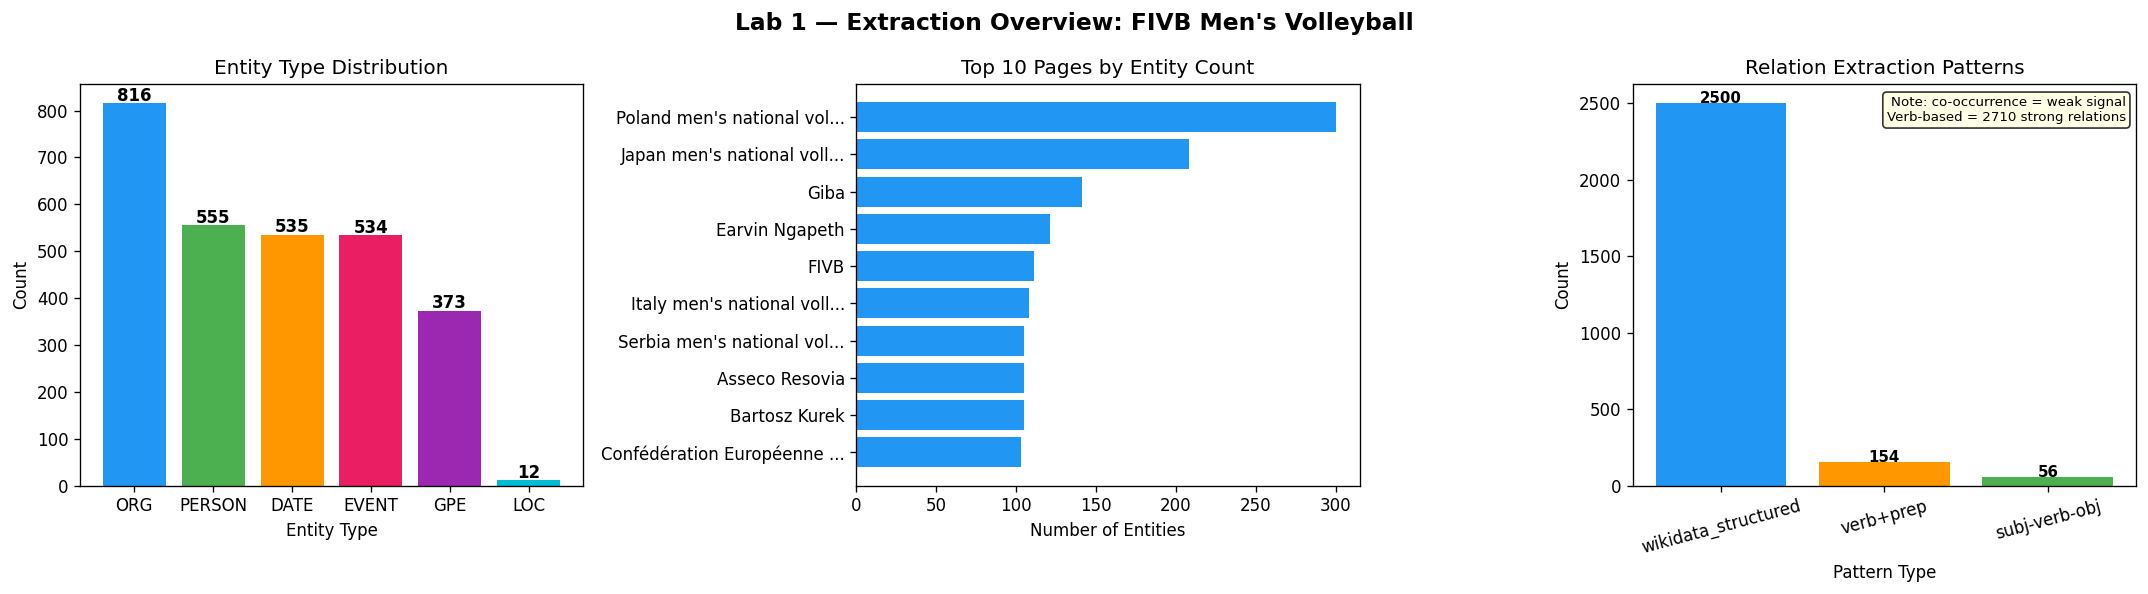

Chart saved → /content/drive/MyDrive/volleyball-kg/data/lab1_overview.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Lab 1 — Extraction Overview: FIVB Men\'s Volleyball', fontsize=14, fontweight='bold')

# ── Plot 1: Entity type distribution ──────────────────────────────────────
entity_counts = df_entities['entity_type'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
axes[0].bar(entity_counts.index, entity_counts.values, color=colors[:len(entity_counts)])
axes[0].set_title('Entity Type Distribution')
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(entity_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── Plot 2: Entities per source page ──────────────────────────────────────
page_counts = df_entities['source_title'].value_counts().head(10)
short_titles = [t[:25] + '...' if len(t) > 25 else t for t in page_counts.index]
axes[1].barh(short_titles[::-1], page_counts.values[::-1], color='#2196F3')
axes[1].set_title('Top 10 Pages by Entity Count')
axes[1].set_xlabel('Number of Entities')

# ── Plot 3: Relation pattern distribution (bar chart — pie was unreadable) ─
if not df_relations.empty:
    # Exclude co-occurrence to show meaningful verb-based patterns clearly
    meaningful = df_relations[df_relations['pattern'] != 'co-occurrence']
    all_counts = df_relations['pattern'].value_counts()
    colors_map = {
        'subj-verb-obj': '#4CAF50',
        'verb+prep':     '#FF9800',
        'co-occurrence': '#B0BEC5'  # grey — less important
    }
    bar_colors = [colors_map.get(p, '#2196F3') for p in all_counts.index]
    axes[2].bar(all_counts.index, all_counts.values, color=bar_colors)
    axes[2].set_title('Relation Extraction Patterns')
    axes[2].set_xlabel('Pattern Type')
    axes[2].set_ylabel('Count')
    for i, v in enumerate(all_counts.values):
        axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)
    # Add note about co-occurrence
    axes[2].tick_params(axis='x', labelrotation=15)
    note = f"Note: co-occurrence = weak signal\nVerb-based = {len(meaningful)} strong relations"
    axes[2].text(0.98, 0.97, note, transform=axes[2].transAxes,
                 fontsize=8, va='top', ha='right',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    axes[2].text(0.5, 0.5, 'No relations\nextracted yet',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Relation Patterns')

plt.tight_layout()
VIZ_PATH = f'{OUTPUT_DIR}/lab1_overview.png'
plt.savefig(VIZ_PATH, bbox_inches='tight')
plt.show()
print(f'Chart saved → {VIZ_PATH}')


In [25]:
print('\n✅ Lab 1 complete!')
print('Files saved to Google Drive:')
print(f'  - {OUTPUT_DIR}/crawler_output.jsonl')
print(f'  - {OUTPUT_DIR}/wikidata_output.jsonl')
print(f'  - {OUTPUT_DIR}/extracted_knowledge.csv')
print(f'  - {OUTPUT_DIR}/extracted_relations.csv')
print(f'  - {OUTPUT_DIR}/lab1_overview.png')
print('\nNext step: Lab 2 — KB Construction & Alignment')



✅ Lab 1 complete!
Files saved to Google Drive:
  - /content/drive/MyDrive/volleyball-kg/data/crawler_output.jsonl
  - /content/drive/MyDrive/volleyball-kg/data/wikidata_output.jsonl
  - /content/drive/MyDrive/volleyball-kg/data/extracted_knowledge.csv
  - /content/drive/MyDrive/volleyball-kg/data/extracted_relations.csv
  - /content/drive/MyDrive/volleyball-kg/data/lab1_overview.png

Next step: Lab 2 — KB Construction & Alignment
